# 01 · From a curve to features, and PCA

**Goal.** Turn each indent into a *feature vector*, put features on equal
footing (standardisation), then use **Principal Component Analysis** to see
the structure in a few dimensions.

You will learn:
1. why we **standardise** features before any distance-based method,
2. how **PCA** finds the directions of greatest variance,
3. how to read a **scree plot** and **component loadings**,
4. that PCA on the *whole curve* (64 numbers) is far richer than on one hardness value.

In [1]:
# --- setup: find the repo (auto-clone on Colab), load helpers, set plot style ---
import os, sys, subprocess
def _find_src():
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None
if _find_src() is None:                    # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)
sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import mecanano_ml as mm
mm.set_style()
print("helpers loaded from:", mm.__file__)

helpers loaded from: /tmp/stage/repo/src/mecanano_ml/__init__.py


In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## 1 · Warm-up: three scalar features

Start simple. Each Al–Cu indent gives hardness `H`, modulus `E` and their
ratio `H/E`. These are **correlated** and live on **different scales**
(GPa vs a unitless ratio), so we z-score them first.

In [3]:
df = mm.load_map("alcu_2um")
feat = ["H", "E", "HE"]
X = df[feat].values
print("raw means:", X.mean(0).round(2), " raw stds:", X.std(0).round(2))
Xs = StandardScaler().fit_transform(X)
print("after z-score -> mean 0, std 1:", Xs.mean(0).round(2), Xs.std(0).round(2))

raw means: [3.980e+00 8.845e+01 4.000e-02]  raw stds: [1.710e+00 1.404e+01 1.000e-02]
after z-score -> mean 0, std 1: [ 0. -0. -0.] [1. 1. 1.]


In [4]:
# how correlated are they?
import numpy as np
print(pd.DataFrame(np.corrcoef(Xs.T), index=feat, columns=feat).round(2))

       H     E    HE
H   1.00  0.84  0.95
E   0.84  1.00  0.66
HE  0.95  0.66  1.00


Because `H`, `E`, `H/E` are correlated, most of their variance lives on **one or two axes** — exactly what PCA will expose.

explained variance ratio: [0.879 0.118 0.002]


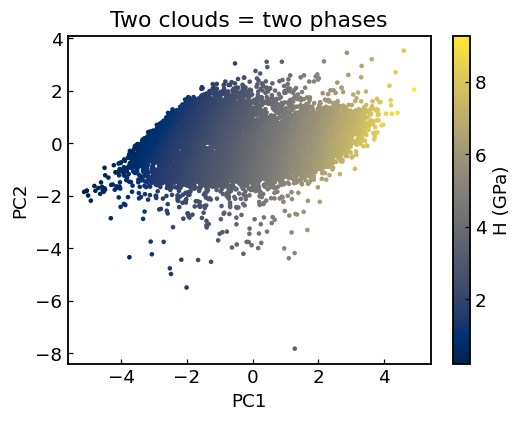

In [5]:
p = PCA().fit(Xs)
print("explained variance ratio:", p.explained_variance_ratio_.round(3))
scores = p.transform(Xs)
fig, ax = plt.subplots(figsize=(5,4))
sctr = ax.scatter(scores[:,0], scores[:,1], c=df["H"], s=4, cmap="cividis")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.colorbar(sctr, label="H (GPa)"); ax.set_title("Two clouds = two phases"); fig.tight_layout()

PC1 already separates the soft matrix from the hard intermetallic. Look at the **loadings** to interpret the axes:

In [6]:
load = pd.DataFrame(p.components_[:2].T, index=feat, columns=["PC1","PC2"]).round(2)
print(load)
print("\nPC1 ~ overall hardness/stiffness magnitude; PC2 ~ the H/E contrast.")

     PC1   PC2
H   0.61 -0.14
E   0.54  0.79
HE  0.57 -0.60

PC1 ~ overall hardness/stiffness magnitude; PC2 ~ the H/E contrast.


## 2 · The real power: PCA on the *whole curve*

A single hardness number throws away the shape of the indentation response.
The AFM grid keeps the full **hardness-vs-depth curve** (64 points). PCA turns
those 64 correlated numbers into a handful of meaningful components.

In [7]:
afm = mm.load_afm_grid()
C = afm["H_curve"].copy()               # (n_indents, 64)
depth = afm["depth_nm"]
# real curves miss a few depth points (surface noise). Trim depth channels that
# are mostly empty, then median-impute the rest -> keep every indent.
from sklearn.impute import SimpleImputer
keep = np.isfinite(C).mean(0) > 0.5
C, depth = C[:, keep], depth[keep]
C = SimpleImputer(strategy="median").fit_transform(C)
print("curve matrix:", C.shape, " depth:", f"{depth[0]:.0f}-{depth[-1]:.0f} nm")
Cs = StandardScaler().fit_transform(C)  # standardise each depth channel

curve matrix: (828, 60)  depth: 5-80 nm


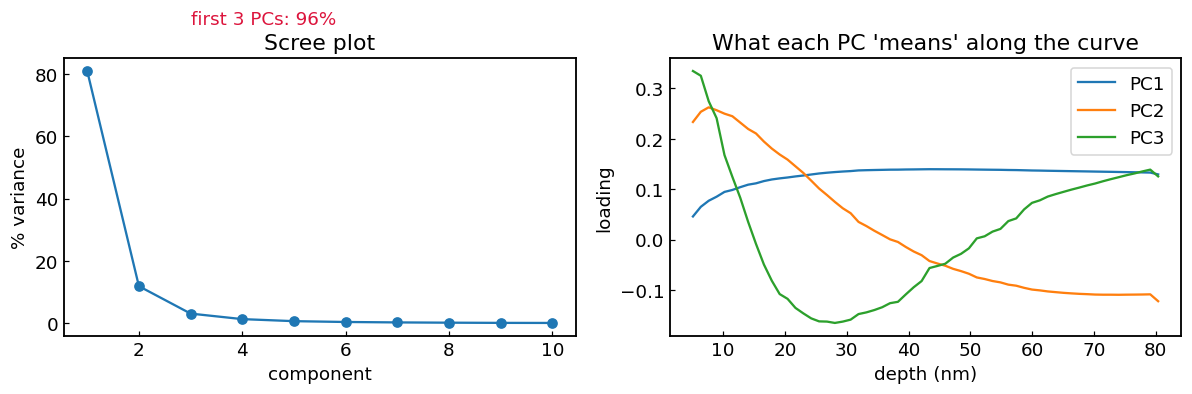

In [8]:
pc = PCA(n_components=10).fit(Cs)
fig, ax = plt.subplots(1,2, figsize=(11,3.8))
ax[0].plot(np.arange(1,11), pc.explained_variance_ratio_*100, "o-")
ax[0].set_xlabel("component"); ax[0].set_ylabel("% variance"); ax[0].set_title("Scree plot")
cum = np.cumsum(pc.explained_variance_ratio_)*100
ax[0].text(3, cum[2], f"first 3 PCs: {cum[2]:.0f}%", color="crimson")
for i in range(3):
    ax[1].plot(depth, pc.components_[i], label=f"PC{i+1}")
ax[1].set_xlabel("depth (nm)"); ax[1].set_ylabel("loading"); ax[1].legend()
ax[1].set_title("What each PC 'means' along the curve"); fig.tight_layout()

A handful of components rebuild the curve almost perfectly — that is the compression PCA buys you, and those few scores are what you feed to clustering (notebook 02).

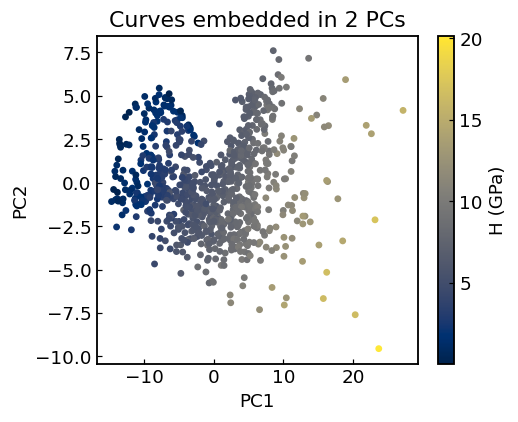

In [9]:
scores = pc.transform(Cs)
fig, ax = plt.subplots(figsize=(5,4))
s = ax.scatter(scores[:,0], scores[:,1], c=afm["H"], s=12, cmap="cividis")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); plt.colorbar(s, label="H (GPa)")
ax.set_title("Curves embedded in 2 PCs"); fig.tight_layout()

## 3 · Non-linear embeddings (t-SNE / UMAP)

PCA is linear. When structure is curved, **t-SNE** and **UMAP** can separate
it better — at the cost of interpretable axes. Use them to *look*, not to
measure distances.

/sessions/busy-friendly-einstein/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/sessions/busy-friendly-einstein/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/sessions/busy-friendly-einstein/tmp/ipykernel_33/3375779649.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.colorbar(sc, ax=ax[0].tolist(), label="H (GPa)"); fig.tight_layout()


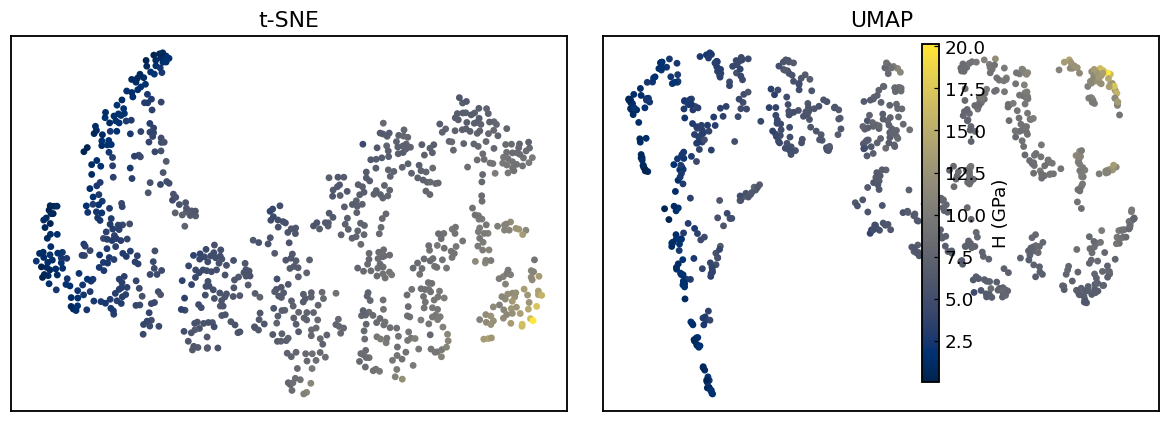

In [10]:
from sklearn.manifold import TSNE
emb = {"t-SNE": TSNE(n_components=2, init="pca", perplexity=30, random_state=0).fit_transform(scores[:, :5])}
try:
    import umap
    emb["UMAP"] = umap.UMAP(n_components=2, random_state=0).fit_transform(scores[:, :5])
except Exception as e:
    print("UMAP not installed — skipping (pip install umap-learn):", type(e).__name__)
fig, ax = plt.subplots(1, len(emb), figsize=(5.4*len(emb), 4), squeeze=False)
for a, (name, Z) in zip(ax[0], emb.items()):
    sc = a.scatter(Z[:,0], Z[:,1], c=afm["H"], s=12, cmap="cividis")
    a.set_title(name); a.set_xticks([]); a.set_yticks([])
fig.colorbar(sc, ax=ax[0].tolist(), label="H (GPa)"); fig.tight_layout()

## Recap
- **Standardise** before PCA / clustering — otherwise GPa-scale features drown a ratio.
- **PCA** rotates to the directions of greatest variance; the **scree plot** tells you how many to keep and the **loadings** tell you what they mean.
- PCA on the **whole curve** keeps shape information a single hardness value discards.

**Next:** `02_clustering_phases.ipynb` — turn these components into a phase map.